In [18]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

import re
import random

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.set_num_threads(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [19]:
#extracting datasets
df_cnbc = pd.read_csv('Dataset/cnbc_headlines.csv')
df_guardian = pd.read_csv('Dataset/guardian_headlines.csv')
df_reuters = pd.read_csv('Dataset/reuters_headlines.csv')

#considering only headlines
headline_cnbc = list(df_cnbc['Headlines'])
headline_guardian = list(df_guardian['Headlines'])
headline_reuters = list(df_reuters['Headlines'])

#list of headlines
headline_list = headline_cnbc + headline_guardian + headline_reuters

print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#cleaning dataset

#filtering empty rows
headline_list = [h for h in headline_list if str(h) != 'nan']
print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#removing spaces in headline
def clean_headline(h):
    h = h.strip() #remove the trailing spaces from either end
    h = re.sub(r'\s+', ' ', h) #replace bigger spaces with a single space
    h = h.encode('ascii', 'ignore').decode()  # remove non-ASCII
    return h

headline_list = [clean_headline(h) for h in headline_list]

No.of headlines in list:  53650
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", nan, "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally']
No.of headlines in list:  53370
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally', "Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says"]


In [20]:
print(len(headline_list))

53370


In [21]:
#vocabulary set
unique_words = set()

for headline in headline_list:
    for letter in list(headline):
        unique_words.add(letter)
    
unique_words = ['<S>', '<E>'] + sorted(unique_words)
vocab_size = len(unique_words)
print("Vocabulary size: ",vocab_size)

#number to word matrix
num2letter_dict = {i:letter for i, letter in enumerate(unique_words)}

#word to number matrix
letter2num_dict = {letter:i for i, letter in enumerate(unique_words)}


Vocabulary size:  84


In [22]:
#building the dataset
block_size = 3

def build_dataset(headline_list):
    context_x = [] #list of all context windows
    targets_y = [] #list of all targets
    for chs in headline_list:
        context_window = [0]*block_size
        for ch in list(chs) + ['<E>']:
            idx = letter2num_dict[ch]
            context_x.append(context_window)
            targets_y.append(idx)
            context_window = context_window[1:] + [idx] #slide context window
        
    #convert the list of context windows and targets into tensors
    context_x = torch.tensor(context_x)
    targets_y = torch.tensor(targets_y)
    return context_x, targets_y

random.seed(42)
random.shuffle(headline_list)
n1 = int(0.8*len(headline_list)) #-> 80% of headline_list
n2 = int(0.9*len(headline_list)) #-> 90% of headline_list

#splitting into train, validation and test datasets
Xtr, Ytr = build_dataset(headline_list[:n1]) #-> 80%
Xval, Yval = build_dataset(headline_list[n1:n2]) #-> 10%
Xtest, Ytest = build_dataset(headline_list[n2:]) #->10%

In [23]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(' '.join(num2letter_dict[ix.item()] for ix in x), '==>', num2letter_dict[y.item()])

<S> <S> <S> ==> T
<S> <S> T ==> w
<S> T w ==> o
T w o ==>  
w o   ==> H
o   H ==> u
  H u ==> a
H u a ==> w
u a w ==> e
a w e ==> i
w e i ==>  
e i   ==> s
i   s ==> t
  s t ==> a
s t a ==> f
t a f ==> f
a f f ==>  
f f   ==> e
f   e ==> x
  e x ==> p


# Python Classes in this MLP — What each method does

## `__init__`
The constructor. Runs **once** when you create the object. Sets up all internal variables (weights, biases, parameters). Think of it as "building the layer before using it."
```python
layer = Linear(30, 200)  # __init__ runs here
```

## `__call__`
Runs when you "call" the object like a function. This is the **forward pass** — takes input `x`, does the computation, returns output.
```python
out = layer(x)  # __call__ runs here
```
Without `__call__`, you'd have to write `layer.forward(x)` every time. `__call__` lets you treat the layer like a function.

## `parameters()`
Returns a list of all tensors that need to be updated by gradient descent. The training loop calls this on every layer to collect all learnable weights in one place:
```python
parameters = []
for layer in layers:
    parameters += layer.parameters()
# now update all of them in one loop
```
Only learnable tensors go here — NOT running stats like `running_mean`/`running_var` in batchnorm, since those aren't updated by gradients.


In [24]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out))/fan_in**0.5 #KAIMING NORMALIZATION
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight #linear equation
        if self.bias is not None:
            self.out += self.bias #check for bias and add
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias]) #array of weights

In [25]:
class BatchNorm1d:
    def __init__(self, dim, epsilon=1e-5, momentum=0.1):
        self.epsilon = epsilon #(epsilon) prevents zero division in norm
        self.momentum = momentum #how fast running stats updates (running_mean and batchnorm mean) during inference
        self.training = True #flag b/w training and inference states
        #--parameters (trained in backprop)--
        self.gamma = torch.ones(dim) #bngain
        self.beta = torch.zeros(dim) #bnbias
        #--buffers (trained with a running "momentum" update)--
        self.running_mean = torch.zeros(dim) #tracks mean across batches for inference
        self.running_var = torch.ones(dim) #tracks variance across batches for inference
        #note : inference -> test/validation set

    def __call__(self, x):
        #calculate forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.epsilon) #batchnorm formula : (x-mu)/sqrt(variance(x) + epsilon)
        self.out = self.gamma * xhat + self.beta #scale and shift (batchnorm formula)
        #update the inference buffers
        if self.training: 
            with torch.no_grad(): #to ensure running mean and running variance are updated without affecting the training parameters
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

In [26]:
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x) #tanh to squash values b/w -1 and 1
        return self.out
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, num_embeddings, embedding_dim): #usually (vocab_size, num_of_embeddings)
        self.weight = torch.randn((num_embeddings, embedding_dim))
        #num_embeddings => num of characters in vocabulary (84 here)
        #embedding_dim => size of embedding vector (10 here)
        #therefore, => torch.randn((84,10)) => same as C matrix
    def __call__(self, IX):
        self.out = self.weight[IX] #embedding lookup (C[Xb], referencing to previous MLP codes)
        return self.out
    def parameters(self):
        return [self.weight]
    
class Sequential: #class defining the neural network architecture
    def __init__(self, layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) #calls each run of list of operation belonging to the layer array [Linear (hidden layer), BatchNorm1d, Tanh, Linear (output layer)]
        self.out = x
        return self.out
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [27]:
torch.manual_seed(42)

In [28]:
n_embd = 10 #char embedding vector dim
n_hidden = 200 #

C = Embedding(vocab_size, n_embd) #embedding characters to random vectors b/w 0 and 1
layers = [Linear(n_embd*block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), Linear(n_hidden, vocab_size)]

with torch.no_grad():
    layers[-1].weight *= 0.1 #normalising vectors to get minimal loss

model = Sequential(layers) #model building
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) #p.nelement() -> no of elements in that tensor
#the print shows the total trainable parameters in network

#enable gradients (backpropagation)
for p in parameters:
    p.requires_grad = True

23284


In [29]:
#moving variables to cuda
for p in parameters:
    p.data = p.data.to(device)
#parameters contain W1, W2, b2, bngain, bnbias etc.
#hence moving parameters to device, moves all these variables too

C.weight.data = C.weight.data.to(device)

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xval = Xval.to(device)
Yval = Yval.to(device)
Xtest = Xtest.to(device)
Ytest = Ytest.to(device)

for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.running_mean = layer.running_mean.to(device)
        layer.running_var = layer.running_var.to(device)
        layer.gamma = layer.gamma.to(device)
        layer.beta = layer.beta.to(device)

In [30]:
#training loop
max_steps = 200000
batch_size = 256
lossi = []

for i in range(max_steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    #forward pass
    emb = C(Xb)
    emb_flat = emb.view(emb.shape[0], -1)
    x = model(emb_flat)
    loss = f.cross_entropy(x, Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    lr = 0.1 if i<150000 else 0.01 #to stop learning rate decay
    for p in parameters:
        p.data += -lr*p.grad
    
    #tracking
    if i%10000 == 0:
        print("Iteration "+f'{i}'+": "+f'{loss.item()}')
    lossi.append(loss.detach().cpu().log10().item())

torch.cuda.empty_cache() 
print("Training complete")

Iteration 0: 5.187173366546631


Iteration 10000: 2.130842685699463
Iteration 20000: 2.153754472732544
Iteration 30000: 2.196803092956543
Iteration 40000: 1.9159170389175415
Iteration 50000: 2.051544189453125
Iteration 60000: 1.8322234153747559
Iteration 70000: 1.8714368343353271
Iteration 80000: 1.9274992942810059
Iteration 90000: 1.896852731704712
Iteration 100000: 1.9008362293243408
Iteration 110000: 2.0048036575317383
Iteration 120000: 1.8625249862670898
Iteration 130000: 1.951231837272644
Iteration 140000: 1.906570553779602
Iteration 150000: 2.0194244384765625
Iteration 160000: 2.057685375213623
Iteration 170000: 1.6474617719650269
Iteration 180000: 1.8751047849655151
Iteration 190000: 1.9700226783752441
Training complete


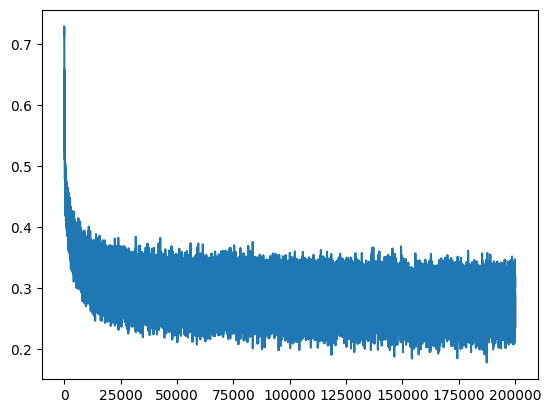

In [31]:
plt.plot(lossi)

In [32]:
#now, sending the layers to "eval" mode
for layer in layers:
    layer.training = False

In [43]:
@torch.no_grad() #decorator : disables gradient tracking
def split_loss(split):
    XXb,YYb = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtest, Ytest)
    }[split]

    #processing in batches and accumulating losses
    losses = []

    for i in range(0, XXb.shape[0], 1000):
        Xbatch = XXb[i:i+1000] #processing X and Y in batches as GPU memory isn't enough
        Ybatch = YYb[i:i+1000]
        #forward pass
        emb = C(Xbatch) #embedding characters
        emb_flat = emb.view(emb.shape[0], -1) #flatten emb to form a hidden layer
        x=model(emb_flat)
        loss=f.cross_entropy(x, Ybatch)
        losses.append(loss.item())
    print(split, sum(losses)/len(losses)) #avg loss obtained in training set
        

split_loss('test')
split_loss('val')


test 1.8817246470186446
val 1.8762382278895244
